<a href="https://colab.research.google.com/github/gracyella26/PROJECT-EA/blob/main/Enterprise_Architecture_Kel_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# 1. IMPORT LIBRARY & LOAD DATA
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-Learn untuk Random Forest & Preprocessing
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# TensorFlow/Keras untuk LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Pengaturan plot
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

# Load Data (Pastikan nama file sesuai dengan yang di-upload ke Colab)
# df = pd.read_csv('nama_file_dataset.csv', sep=';', decimal=',')

# Simulasi (Hapus bagian ini jika sudah meload data asli)
print("Library berhasil di-import dan data siap diproses!")

Library berhasil di-import dan data siap diproses!


In [ ]:
# ─── LOAD DATA dari UCI ML Repository ─────────────────────────────────────────
# Opsi A: otomatis via ucimlrepo
try:
    from ucimlrepo import fetch_ucirepo
    steel_industry = fetch_ucirepo(id=851)
    df = steel_industry.data.features.copy()
    df['CO2'] = steel_industry.data.targets.values
    print('✅ Data berhasil dimuat via ucimlrepo')
except Exception:
    # Opsi B: upload manual (Google Colab)
    from google.colab import files
    uploaded = files.upload()
    FILE_PATH = list(uploaded.keys())[0]
    df_raw = pd.read_csv(FILE_PATH, sep=';', decimal=',')
    df_raw = df_raw.rename(columns={'CO2(tCO2)': 'CO2'})
    df = df_raw.copy()
    print('✅ Data berhasil dimuat via upload manual')

print(f'   Jumlah baris  : {len(df):,}')
print(f'   Jumlah kolom  : {len(df.columns)}')
df.head(3)

Saving Steel industry data ML ready preprocessing.csv to Steel industry data ML ready preprocessing.csv
✅ Data berhasil dimuat via upload manual
   Jumlah baris  : 35,040
   Jumlah kolom  : 15


,date,Month,Hour,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Is_Light,Is_Medium,Is_max
0,1,1,00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,0,0,1,0,0
1,1,1,00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,0,0,1,0,0
2,1,1,00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,0,0,1,0,0


In [ ]:
# ==========================================
# 2. PRA-PEMROSESAN & REKAYASA FITUR
# ==========================================

# 2.1 Membersihkan format jam (dari '00:15:00' menjadi angka 0)
if 'Hour' in df.columns:
    df['Hour_int'] = df['Hour'].apply(lambda x: int(str(x).split(':')[0]))

# 2.2 Membuat Siklus Waktu (Sine & Cosine)
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour_int'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour_int'] / 24)
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# 2.3 Standarisasi Nama Kolom (Agar lebih mudah diketik)
df = df.rename(columns={
    'Lagging_Current_Reactive.Power_kVarh': 'Lagging_kVarh',
    'Leading_Current_Reactive_Power_kVarh': 'Leading_kVarh',
    'Lagging_Current_Power_Factor': 'Lagging_PF',
    'Leading_Current_Power_Factor': 'Leading_PF',
    'CO2(tCO2)': 'CO2'
})

# 2.4 Seleksi Fitur (USAGE_KWH SENGAGA DIHAPUS)
FEATURE_COLS = [
    'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos',
    'Lagging_kVarh', 'Leading_kVarh', 'Lagging_PF', 'Leading_PF',
    'NSM', 'WeekStatus', 'Day_of_week',
    'Is_Light', 'Is_Medium', 'Is_max'
]
TARGET_COL = 'CO2'

X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

print(f"Total fitur yang digunakan: {len(FEATURE_COLS)} kolom (Tanpa Usage_kWh)")

Total fitur yang digunakan: 14 kolom (Tanpa Usage_kWh)


In [ ]:
# ==========================================
# 3. TEMPORAL SPLIT (PEMBAGIAN DATA TIME-SERIES)
# ==========================================
SPLIT_RATIO = 0.80
split_idx = int(len(df) * SPLIT_RATIO)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Data Training (80%): {len(X_train)} baris")
print(f"Data Testing  (20%): {len(X_test)} baris")

Data Training (80%): 28032 baris
Data Testing  (20%): 7008 baris


In [ ]:
# ==========================================
# 4. RANDOM FOREST REGRESSOR (MODEL DIAGNOSIS)
# ==========================================
print("Mencari parameter terbaik untuk Random Forest (tunggu sebentar)...")

# Membatasi parameter agar tidak overfitting
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [5],
    'max_features': [0.5, 'sqrt']
}

base_rf = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(base_rf, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Eksekusi model terbaik
rf_best = grid_search.best_estimator_
y_pred_rf = rf_best.predict(X_test)

# Evaluasi RF
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("\n--- HASIL RANDOM FOREST ---")
print(f"R2 Score : {rf_r2:.4f}")
print(f"MAE      : {rf_mae:.4f}")
print(f"Parameter: {grid_search.best_params_}")

Mencari parameter terbaik untuk Random Forest (tunggu sebentar)...

--- HASIL RANDOM FOREST ---
R2 Score : 0.9886
MAE      : 0.0008
Parameter: {'max_depth': 15, 'max_features': 0.5, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200}


In [ ]:
# ==========================================
# 5. LSTM (MODEL FORECASTING / EARLY WARNING)
# ==========================================
print("Menyiapkan data untuk LSTM...")

# 5.1 Normalisasi (Hanya fit di data train untuk hindari leakage)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

# 5.2 Membuat Sequence (Window 6 jam = 24 timestep)
SEQ_LEN = 24

def make_sequences(X_data, y_data, seq_len):
    X_seq, y_seq = [], []
    for i in range(len(X_data) - seq_len):
        X_seq.append(X_data[i : i + seq_len])
        y_seq.append(y_data[i + seq_len])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = make_sequences(X_train_scaled, y_train_scaled, SEQ_LEN)
X_test_seq, y_test_seq = make_sequences(X_test_scaled, y_test_scaled, SEQ_LEN)
y_test_aligned = y_test[SEQ_LEN:] # Selaraskan y_test asli

# 5.3 Arsitektur LSTM
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, X_train_seq.shape[2])),
    Dropout(0.2), # Matikan neuron acak agar tidak hafal mati
    LSTM(32),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')

# 5.4 Training dengan Early Stopping (Rem otomatis)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Memulai proses training LSTM...")
history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0 # Ubah ke 1 jika ingin melihat progress bar
)

# 5.5 Prediksi & Evaluasi
y_pred_lstm_scaled = lstm_model.predict(X_test_seq, verbose=0)
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled).flatten()

lstm_mae = mean_absolute_error(y_test_aligned, y_pred_lstm)
lstm_rmse = np.sqrt(mean_squared_error(y_test_aligned, y_pred_lstm))
lstm_r2 = r2_score(y_test_aligned, y_pred_lstm)

print("\n--- HASIL LSTM ---")
print(f"R2 Score : {lstm_r2:.4f}")
print(f"MAE      : {lstm_mae:.4f}")

Menyiapkan data untuk LSTM...
Memulai proses training LSTM...

--- HASIL LSTM ---
R2 Score : 0.8868
MAE      : 0.0028


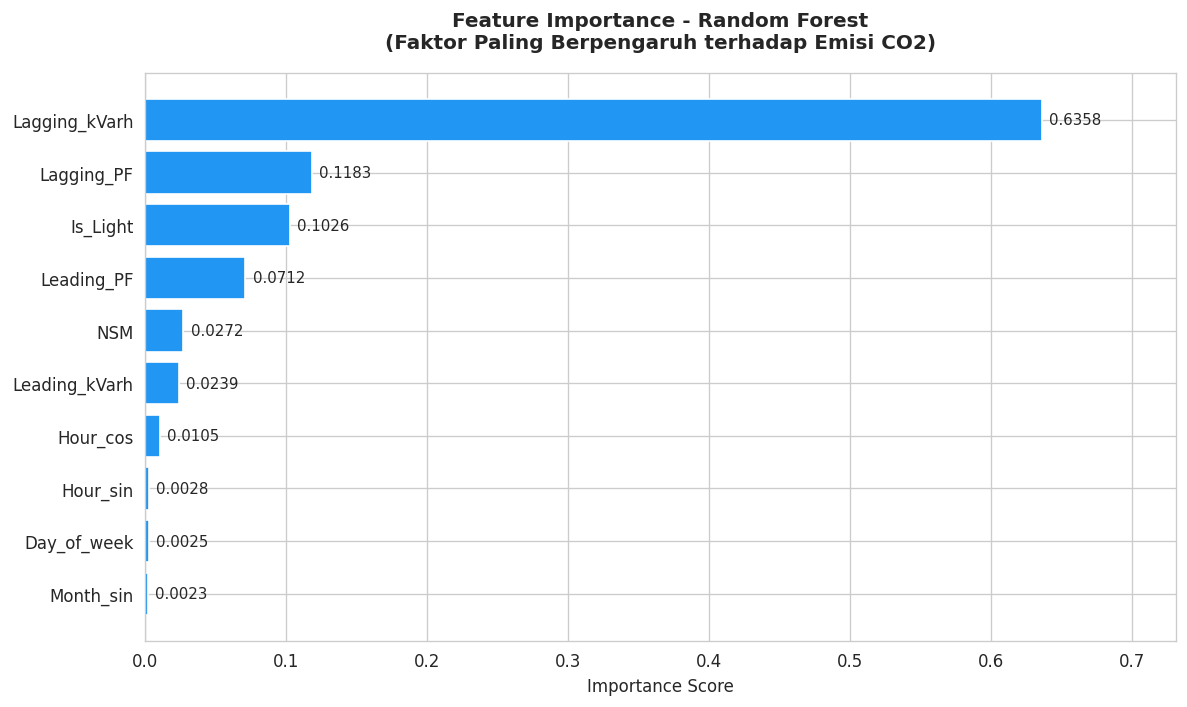


Kesimpulan: Fitur kualitas daya (Lagging_kVarh / Power Factor) kini menjadi penentu utama, bukan lagi Usage_kWh.


In [ ]:
# ==========================================
# 6. VISUALISASI RANDOM FOREST (FEATURE IMPORTANCE)
# ==========================================
import matplotlib.pyplot as plt
import pandas as pd

# Mengambil nilai tingkat kepentingan fitur dari model terbaik
importances = rf_best.feature_importances_
feat_df = pd.DataFrame({
    'Fitur': FEATURE_COLS,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Mengambil 10 fitur teratas
top10 = feat_df.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10['Fitur'][::-1], top10['Importance'][::-1], color='#2196F3', edgecolor='white')

# Menambahkan label angka di ujung batang
for bar, val in zip(bars, top10['Importance'][::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_title('Feature Importance - Random Forest\n(Faktor Paling Berpengaruh terhadap Emisi CO2)',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Importance Score')
ax.set_xlim(0, top10['Importance'].max() * 1.15)

plt.tight_layout()
plt.show()

print("\nKesimpulan: Fitur kualitas daya (Lagging_kVarh / Power Factor) kini menjadi penentu utama, bukan lagi Usage_kWh.")

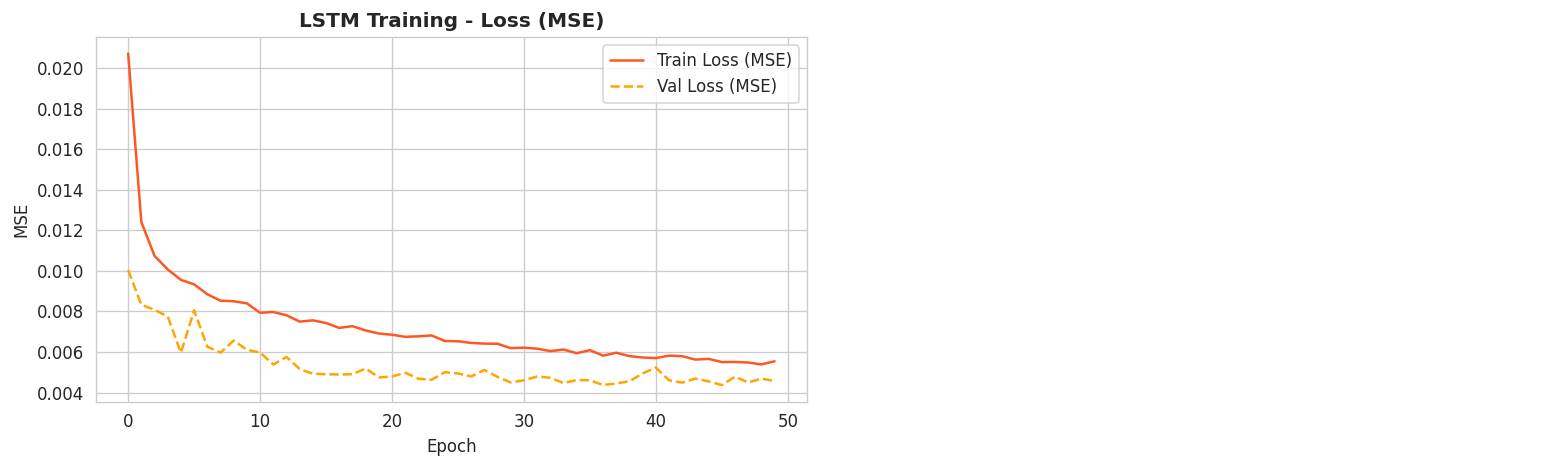

In [ ]:
# ==========================================
# 7. VISUALISASI TRAINING LSTM (LOSS CURVE)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Plot MSE (Mean Squared Error)
axes[0].plot(history.history['loss'], label='Train Loss (MSE)', color='#FF5722')
axes[0].plot(history.history['val_loss'], label='Val Loss (MSE)', color='orange', linestyle='--')
axes[0].set_title('LSTM Training - Loss (MSE)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()

# Jika ingin menampilkan metrik lain (opsional, karena di code compile kita pakai MSE saja)
# Tapi untuk keindahan visual, cukup plot loss yang utama
axes[1].axis('off') # Kosongkan panel kedua atau bisa diisi grafik lain jika butuh

plt.tight_layout()
plt.show()

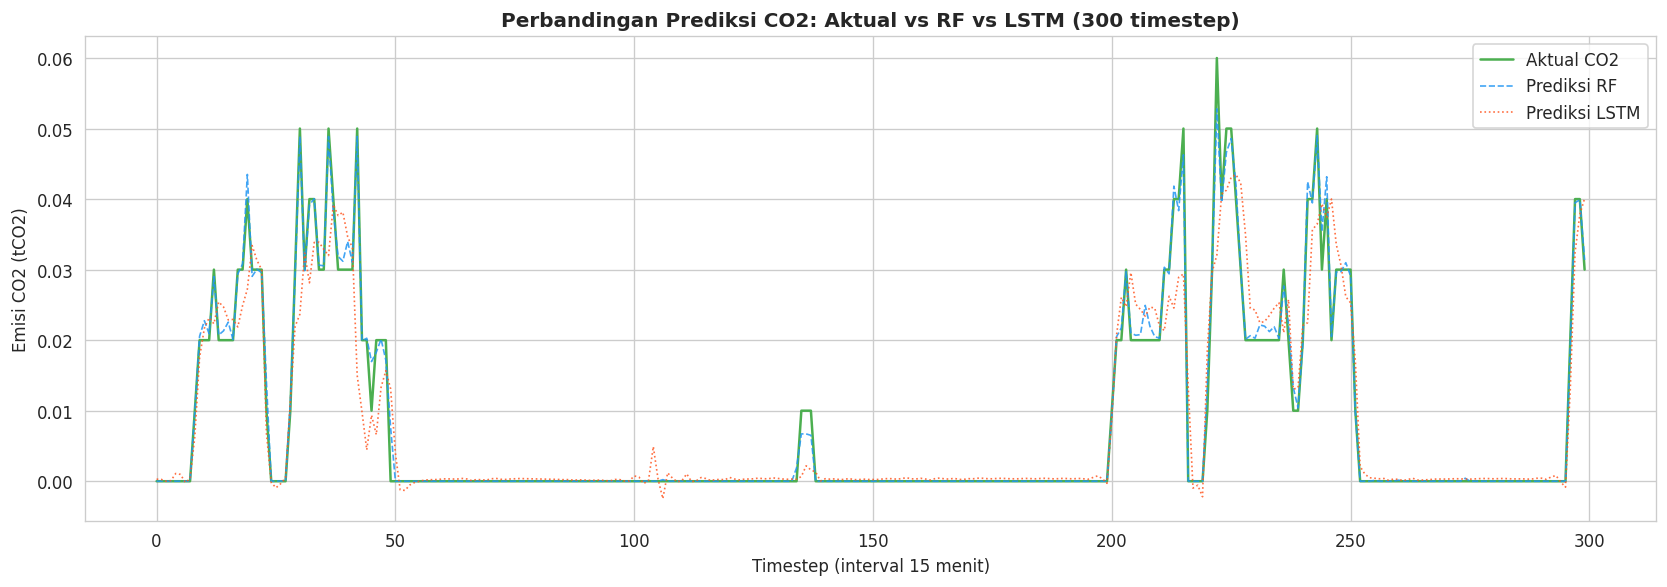

In [ ]:
# ==========================================
# 8. VISUALISASI KOMPARASI: AKTUAL vs RF vs LSTM
# ==========================================
N_PLOT = 300 # Menampilkan 300 titik data (sekitar 3 hari operasional)

# Penting: LSTM memprediksi mulai dari index ke-24 (karena butuh histori 6 jam).
# Jadi kita harus menyelaraskan potongan datanya.
actual_slice = y_test_aligned[:N_PLOT]
lstm_slice = y_pred_lstm[:N_PLOT]
rf_slice = y_pred_rf[SEQ_LEN : SEQ_LEN + N_PLOT] # RF disesuaikan offset-nya

fig, ax = plt.subplots(figsize=(14, 5))

# Plot garis aktual (hijau)
ax.plot(actual_slice, label='Aktual CO2', color='#4CAF50', linewidth=1.5)

# Plot RF (biru)
ax.plot(rf_slice, label='Prediksi RF', color='#2196F3', linewidth=1.0, linestyle='--', alpha=0.85)

# Plot LSTM (merah/oranye)
ax.plot(lstm_slice, label='Prediksi LSTM', color='#FF5722', linewidth=1.0, linestyle=':', alpha=0.85)

ax.set_title('Perbandingan Prediksi CO2: Aktual vs RF vs LSTM (300 timestep)', fontsize=12, fontweight='bold')
ax.set_xlabel('Timestep (interval 15 menit)')
ax.set_ylabel('Emisi CO2 (tCO2)')
ax.legend()

plt.tight_layout()
plt.show()

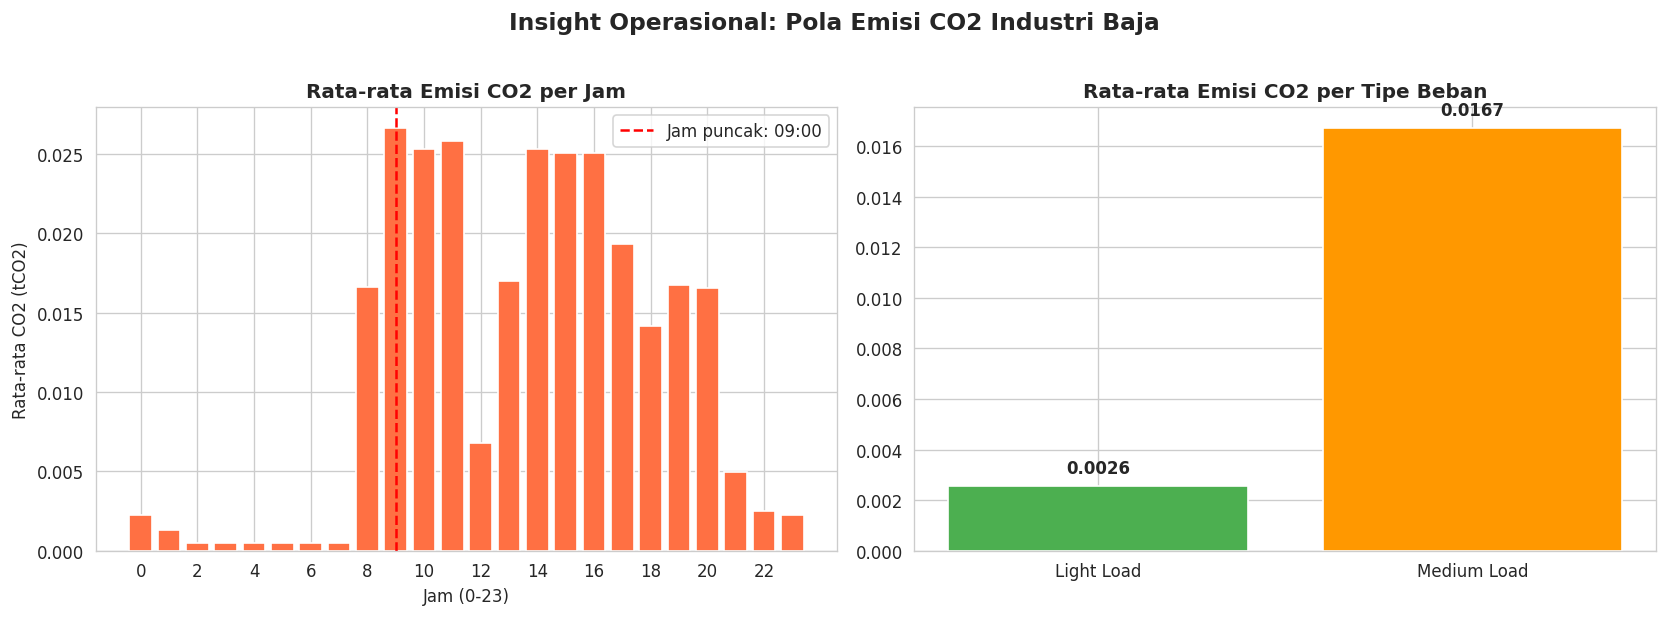


--- REKOMENDASI UNTUK GREEN EA (TOGAF PHASE B & C) ---
1. SISTEM ALERT: Prioritaskan pengawasan ketat pada jam puncak emisi (09:00).
2. LOAD SHIFTING: Kurangi operasional 'Medium/Max Load' di jam sibuk untuk meratakan beban energi.
3. MONITORING: Integrasikan sensor daya reaktif (Lagging kVarh) ke dalam arsitektur IoT secara real-time karena pengaruhnya sangat dominan.


In [ ]:
# ==========================================
# 9. EKSTRAKSI INSIGHT OPERASIONAL UNTUK GREEN EA
# ==========================================
# Pastikan menggunakan dataframe awal yang belum displit atau dinormalkan agar angkanya asli
hourly_co2 = df.groupby('Hour_int')['CO2'].mean()
peak_hour = hourly_co2.idxmax()

light_co2 = df[df['Is_Light'] == 1]['CO2'].mean()
medium_co2 = df[df['Is_Medium'] == 1]['CO2'].mean()
# max_co2 = df[df['Is_max'] == 1]['CO2'].mean() # Abaikan jika NaN/tidak ada di data test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafik 1: Rata-rata Emisi per Jam
axes[0].bar(hourly_co2.index, hourly_co2.values, color='#FF7043', edgecolor='white')
axes[0].axvline(x=peak_hour, color='red', linestyle='--', linewidth=1.5, label=f'Jam puncak: {peak_hour:02d}:00')
axes[0].set_title('Rata-rata Emisi CO2 per Jam', fontweight='bold')
axes[0].set_xlabel('Jam (0-23)')
axes[0].set_ylabel('Rata-rata CO2 (tCO2)')
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()

# Grafik 2: Rata-rata Emisi per Tipe Beban (Load Type)
load_labels = ['Light Load', 'Medium Load']
load_vals = [light_co2, medium_co2]

bars2 = axes[1].bar(load_labels, load_vals, color=['#4CAF50', '#FF9800'], edgecolor='white')
for bar, val in zip(bars2, load_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Rata-rata Emisi CO2 per Tipe Beban', fontweight='bold')

plt.suptitle('Insight Operasional: Pola Emisi CO2 Industri Baja', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Mencetak teks kesimpulan untuk bahan laporan Bab 4
print("\n--- REKOMENDASI UNTUK GREEN EA (TOGAF PHASE B & C) ---")
print(f"1. SISTEM ALERT: Prioritaskan pengawasan ketat pada jam puncak emisi ({peak_hour:02d}:00).")
print(f"2. LOAD SHIFTING: Kurangi operasional 'Medium/Max Load' di jam sibuk untuk meratakan beban energi.")
print(f"3. MONITORING: Integrasikan sensor daya reaktif (Lagging kVarh) ke dalam arsitektur IoT secara real-time karena pengaruhnya sangat dominan.")